<div style="background: white;
            padding: 15px 20px;
            border-radius: 8px;
            border-left: 6px solid #9b5de5;
            font-family: 'Segoe UI', sans-serif;
            color: #1a1a1a;
            max-width: 800px;">

<h1 style="margin-bottom: 5px;">NB02: Fashion Trend Data Collection</h1>

<p style="font-weight: bold; margin-top: 0;">Fashion & Economy Cycles · ML Research Project · 2026</p>

<ul>
    <li>📅 <strong>Date:</strong> 19th July 2026</li>
    <li>🎯 <strong>Purpose:</strong> Pull Google Trends search volume data for maximalist and minimalist fashion keywords, build a composite Fashion Index, and save it ready for merging with economic data in NB03</li>
</ul>

<p><strong>Input:</strong></p>
<ul>
    <li>Google Trends via <code>pytrends</code> library</li>
</ul>

<p><strong>Outputs:</strong></p>
<ul>
    <li><code>../data/raw/fashion_trends_raw.csv</code> — raw Google Trends search volumes per keyword</li>
    <li><code>../data/processed/fashion_index.csv</code> — composite maximalism vs minimalism fashion index</li>
    <li><code>../figures/keyword_trends.png</code> — individual keyword trend lines</li>
    <li><code>../figures/fashion_index.png</code> — composite fashion index over time</li>
</ul>

<p><strong>Key Techniques Used:</strong></p>
<ul>
    <li>Google Trends pull via <code>pytrends</code> with rate limiting</li>
    <li>Keyword grouping into maximalist and minimalist baskets</li>
    <li>Z-score normalisation across keywords</li>
    <li>Composite index construction by averaging keyword scores</li>
    <li>Fashion cycle visualisation with recession shading</li>
</ul>

<p><strong>Workflow:</strong> Define Keywords → Pull Trends → Normalise → Build Index → Visualise → Save</p>

</div>

## ⚙️ Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pytrends.request import TrendReq
import time
import warnings

warnings.filterwarnings("ignore")
plt.style.use("dark_background")
sns.set_palette("coolwarm")

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 🎨 Section 1: Define Fashion Keywords

### 📍 Define Maximalist and Minimalist Keyword Baskets

We split fashion keywords into two opposing aesthetic categories. Maximalist keywords represent loud, expressive, status-driven fashion that tends to flourish during economic booms when consumers feel confident and want to display wealth. Minimalist keywords represent quiet, restrained, functional fashion that tends to emerge during downturns when consumers pull back and prioritise value over display.

The keywords were chosen to span the full 21-year period and represent genuinely distinct aesthetic moments — logomania peaked around 2018-2019, quiet luxury emerged around 2022-2023, Y2K resurged around 2021-2022. Each keyword needs enough search volume to produce a meaningful signal in Google Trends — very niche terms would return too much noise.

In [3]:
# Maximalist keywords — loud, expressive, status-driven fashion
# These should peak during economic booms when consumers feel confident
MAXIMALIST_KEYWORDS = [
    "logomania",
    "neon fashion",
    "mini skirt",
    "sequin outfit",
    "Y2K fashion"
]

# Minimalist keywords — quiet, restrained, value-focused fashion
# These should peak during downturns when consumers pull back
MINIMALIST_KEYWORDS = [
    "quiet luxury",
    "capsule wardrobe",
    "neutral outfit",
    "loafers outfit",
    "maxi skirt"
]

# Date range matching NB01 exactly so the datasets align perfectly when merged
START_DATE = "2005-01-01"
END_DATE   = "2025-12-31"

print(f"✅ Keywords defined")
print(f"📈 Maximalist ({len(MAXIMALIST_KEYWORDS)}): {MAXIMALIST_KEYWORDS}")
print(f"📉 Minimalist ({len(MINIMALIST_KEYWORDS)}): {MINIMALIST_KEYWORDS}")
print(f"📅 Period: {START_DATE} → {END_DATE}")

✅ Keywords defined
📈 Maximalist (5): ['logomania', 'neon fashion', 'mini skirt', 'sequin outfit', 'Y2K fashion']
📉 Minimalist (5): ['quiet luxury', 'capsule wardrobe', 'neutral outfit', 'loafers outfit', 'maxi skirt']
📅 Period: 2005-01-01 → 2025-12-31


## 📥 Section 2: Pull Google Trends Data

### 📍 Step 1: Initialise pytrends Connection

pytrends is an unofficial Python wrapper for the Google Trends API. We set the language to English and timezone to US Eastern (360 minutes offset from UTC) since our economic data is US-based and we want search trends from the same market.

Google Trends has strict rate limiting — if we send too many requests too quickly it returns errors. We handle this by adding a sleep delay between each keyword pull and pulling keywords one at a time rather than in batches.

In [4]:
# Initialise the pytrends connection
# hl="en-US" sets language to English
# tz=360 sets timezone to US Central — consistent with our US economic data
pytrends = TrendReq(hl="en-US", tz=360)

print("✅ pytrends connection initialised")
print("💡 Note: Google Trends rate limits requests — we pull one keyword at a time with delays")

✅ pytrends connection initialised
💡 Note: Google Trends rate limits requests — we pull one keyword at a time with delays


### 📍 Step 2: Pull Trends for Each Keyword

We pull each keyword individually rather than in groups of five (pytrends' default batch size) because Google Trends normalises within each batch — if keywords have very different popularity levels, the less popular ones get compressed to near-zero. Pulling individually and normalising ourselves gives a fairer comparison across keywords.

We use monthly frequency (gprop="" for web search, timeframe spanning the full date range) and add a 2-second delay between each request to avoid hitting Google's rate limit.

In [5]:
# Store results for each keyword
all_trends = {}

# Pull maximalist and minimalist keywords together in one loop
all_keywords = MAXIMALIST_KEYWORDS + MINIMALIST_KEYWORDS

for keyword in all_keywords:
    print(f"⏳ Pulling: {keyword}...")

    try:
        # Build the payload — tells pytrends what to search for
        # timeframe uses YYYY-MM-DD format for the full date range
        # geo="US" restricts to US searches to match our economic data
        # gprop="" means web search (not YouTube, news, or image search)
        pytrends.build_payload(
            [keyword],
            timeframe=f"{START_DATE} {END_DATE}",
            geo="US",
            gprop=""
        )

        # Pull the interest over time data
        # Returns a DataFrame with dates as index and keyword as column
        # Values are 0-100 where 100 = peak search interest in the period
        df = pytrends.interest_over_time()

        if not df.empty:
            # Drop the isPartial column — it flags incomplete recent data
            # and is not needed for our analysis
            df = df.drop(columns=["isPartial"], errors="ignore")
            all_trends[keyword] = df[keyword]
            print(f"   ✅ {keyword}: {len(df)} months pulled")
        else:
            print(f"   ⚠️ {keyword}: no data returned")

    except Exception as e:
        print(f"   ❌ {keyword}: error — {e}")

    # Wait 2 seconds between requests to avoid Google rate limiting
    time.sleep(2)

print(f"\n✅ All keywords pulled — {len(all_trends)} successful")

⏳ Pulling: logomania...
   ✅ logomania: 252 months pulled
⏳ Pulling: neon fashion...
   ✅ neon fashion: 252 months pulled
⏳ Pulling: mini skirt...
   ✅ mini skirt: 252 months pulled
⏳ Pulling: sequin outfit...
   ✅ sequin outfit: 252 months pulled
⏳ Pulling: Y2K fashion...
   ✅ Y2K fashion: 252 months pulled
⏳ Pulling: quiet luxury...
   ✅ quiet luxury: 252 months pulled
⏳ Pulling: capsule wardrobe...
   ✅ capsule wardrobe: 252 months pulled
⏳ Pulling: neutral outfit...
   ✅ neutral outfit: 252 months pulled
⏳ Pulling: loafers outfit...
   ✅ loafers outfit: 252 months pulled
⏳ Pulling: maxi skirt...
   ✅ maxi skirt: 252 months pulled

✅ All keywords pulled — 10 successful


### 📍 Step 3: Combine Into a Single DataFrame

In [8]:
# Combine all keyword series into one DataFrame
# pd.concat aligns by date index automatically
df_raw = pd.concat(all_trends.values(), axis=1)
df_raw.columns = list(all_trends.keys())
df_raw.index.name = "Date"

# Ensure the index is datetime
df_raw.index = pd.to_datetime(df_raw.index)

print(f"✅ Combined DataFrame created")
print(f"📐 Shape  : {df_raw.shape}")
print(f"📅 Range  : {df_raw.index[0].date()} → {df_raw.index[-1].date()}")
print(f"\n🔍 Missing values:")
print(df_raw.isnull().sum())
print(f"\n🔍 Preview:")
df_raw.tail()

✅ Combined DataFrame created
📐 Shape  : (252, 10)
📅 Range  : 2005-01-01 → 2025-12-01

🔍 Missing values:
logomania           0
neon fashion        0
mini skirt          0
sequin outfit       0
Y2K fashion         0
quiet luxury        0
capsule wardrobe    0
neutral outfit      0
loafers outfit      0
maxi skirt          0
dtype: int64

🔍 Preview:


,logomania,neon fashion,mini skirt,sequin outfit,Y2K fashion,quiet luxury,capsule wardrobe,neutral outfit,loafers outfit,maxi skirt
Date,,,,,,,,,,
2025-08-01,0,25,69,36,75,50,65,59,88,58
2025-09-01,11,25,69,48,85,48,62,61,93,52
2025-10-01,14,29,92,53,60,54,61,71,88,48
2025-11-01,19,32,70,58,58,77,65,83,100,46
2025-12-01,9,37,64,94,57,100,100,100,98,39


## 💾 Section 3: Save Raw Data

### 📍 Save Raw Trends Before Normalisation

In [7]:
RAW_PATH = "../data/raw/fashion_trends_raw.csv"
df_raw.to_csv(RAW_PATH)

print(f"✅ Raw fashion trends saved to {RAW_PATH}")

✅ Raw fashion trends saved to ../data/raw/fashion_trends_raw.csv


## 📊 Section 4: Visualise Individual Keywords

### 📍 Plot Each Keyword's Search Volume Over Time

Before building the composite index, we inspect each keyword individually. This serves two purposes: it confirms the data pulled correctly, and it lets us check whether each keyword's peak timing makes intuitive sense. For example, Y2K fashion should peak around 2021-2022 when the trend resurged, and quiet luxury should emerge around 2022-2023. If a keyword shows a flat line or random noise,
it may be too niche and we would consider replacing it.

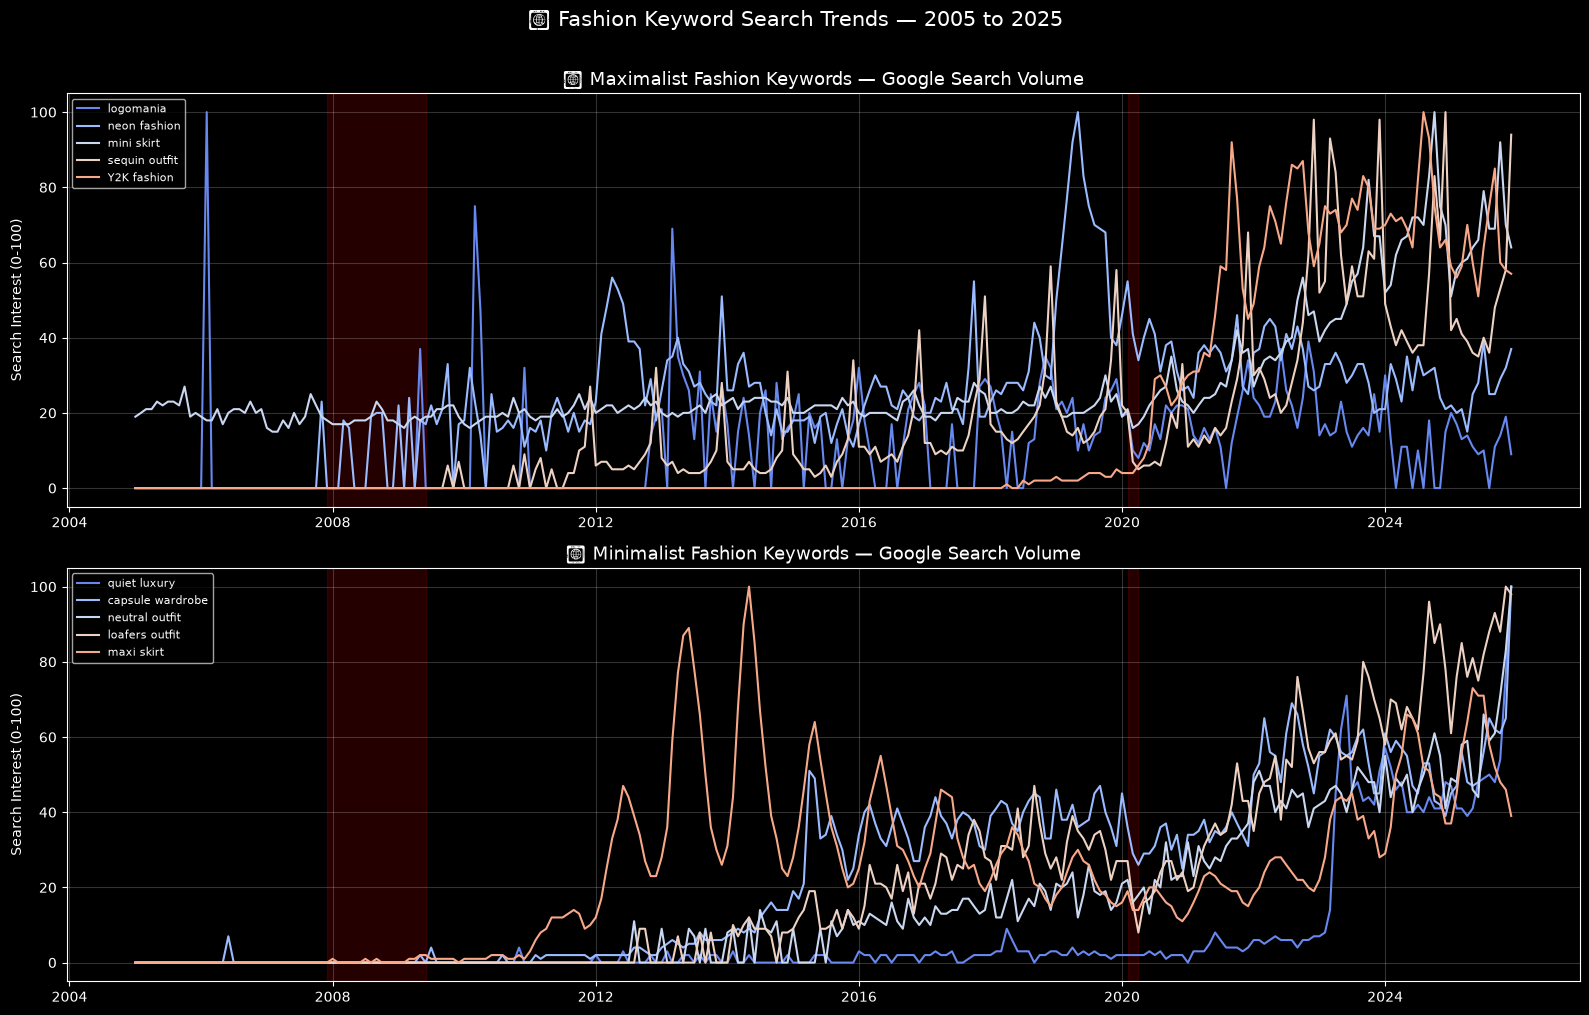

💾 Saved to ../figures/keyword_trends.png


In [9]:
# Define recession periods for shading — same as NB01
RECESSIONS = [
    ("2007-12-01", "2009-06-01"),
    ("2020-02-01", "2020-04-01"),
]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot maximalist keywords on top chart
for kw in MAXIMALIST_KEYWORDS:
    if kw in df_raw.columns:
        axes[0].plot(df_raw.index, df_raw[kw], linewidth=1.5, label=kw)

for rec_start, rec_end in RECESSIONS:
    axes[0].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

axes[0].set_title("📈 Maximalist Fashion Keywords — Google Search Volume", fontsize=13)
axes[0].set_ylabel("Search Interest (0-100)")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].grid(alpha=0.2)

# Plot minimalist keywords on bottom chart
for kw in MINIMALIST_KEYWORDS:
    if kw in df_raw.columns:
        axes[1].plot(df_raw.index, df_raw[kw], linewidth=1.5, label=kw)

for rec_start, rec_end in RECESSIONS:
    axes[1].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

axes[1].set_title("📉 Minimalist Fashion Keywords — Google Search Volume", fontsize=13)
axes[1].set_ylabel("Search Interest (0-100)")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(alpha=0.2)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("🔍 Fashion Keyword Search Trends — 2005 to 2025", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("../figures/keyword_trends.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/keyword_trends.png")

## 🔧 Section 5: Build the Fashion Index

### 📍 Step 1: Normalise Each Keyword to Z-Scores

Google Trends values are relative within each keyword — a score of 100 means peak interest for that keyword, but a keyword that peaked at 100 might have far less absolute search volume than another. We cannot directly compare raw scores across keywords.

Z-score normalisation converts each keyword to a common scale by expressing values as standard deviations from that keyword's own mean. This means a z-score of +2 for "logomania" and a z-score of +2 for "quiet luxury" both mean "this keyword was 2 standard deviations above its own average" — making them directly comparable.

In [10]:
df_normalised = df_raw.copy()

# Z-score each keyword independently
# (value - mean) / std gives mean=0, std=1 for each column
for col in df_normalised.columns:
    mean = df_normalised[col].mean()
    std  = df_normalised[col].std()
    df_normalised[col] = (df_normalised[col] - mean) / std

print("✅ Z-score normalisation complete")
print(f"\n📊 Sample statistics after normalisation:")
df_normalised.describe().round(3)

✅ Z-score normalisation complete

📊 Sample statistics after normalisation:


,logomania,neon fashion,mini skirt,sequin outfit,Y2K fashion,quiet luxury,capsule wardrobe,neutral outfit,loafers outfit,maxi skirt
count,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000,252.000
mean,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-0.805,-1.412,-0.815,-0.784,-0.578,-0.456,-1.052,-0.800,-0.829,-1.108
25%,-0.805,-0.483,-0.509,-0.784,-0.578,-0.456,-1.052,-0.800,-0.829,-1.061
50%,-0.069,-0.019,-0.386,-0.385,-0.578,-0.367,0.092,-0.314,-0.412,-0.116
75%,0.593,0.504,-0.142,0.294,0.364,-0.279,0.754,0.375,0.460,0.553
max,6.554,4.394,4.385,3.900,2.877,5.463,3.435,4.310,2.961,3.505


### 📍 Step 2: Build Composite Maximalism and Minimalism Scores

We average the z-scores of all maximalist keywords into a single Maximalism Score, and all minimalist keywords into a single Minimalism Score. Averaging reduces noise — if one keyword has an unusual spike due to a celebrity moment rather than a broad trend, the other keywords in the basket dilute its effect.

We then compute a net Fashion Index = Maximalism Score minus Minimalism Score. A positive value means maximalism is dominating search interest relative to minimalism. A negative value means minimalism is dominating. This single number is what we will correlate with economic indicators in NB03.

In [11]:
# Average z-scores across all maximalist keywords
# Only include keywords that were successfully pulled
max_cols = [kw for kw in MAXIMALIST_KEYWORDS if kw in df_normalised.columns]
min_cols = [kw for kw in MINIMALIST_KEYWORDS  if kw in df_normalised.columns]

df_index = pd.DataFrame(index=df_normalised.index)

# Maximalism score — average of all maximalist keyword z-scores
df_index["maximalism_score"] = df_normalised[max_cols].mean(axis=1)

# Minimalism score — average of all minimalist keyword z-scores
df_index["minimalism_score"] = df_normalised[min_cols].mean(axis=1)

# Net fashion index — positive = maximalism dominating, negative = minimalism dominating
df_index["fashion_index"] = df_index["maximalism_score"] - df_index["minimalism_score"]

print("✅ Fashion index constructed")
print(f"\n📊 Fashion Index summary:")
print(df_index.describe().round(3))

✅ Fashion index constructed

📊 Fashion Index summary:
       maximalism_score  minimalism_score  fashion_index
count           252.000           252.000        252.000
mean             -0.000            -0.000          0.000
std               0.722             0.862          0.422
min              -0.879            -0.849         -1.799
25%              -0.573            -0.839         -0.179
50%              -0.172            -0.081          0.044
75%               0.459             0.260          0.230
max               1.829             3.357          1.479


### 📍 Step 3: Visualise the Fashion Index

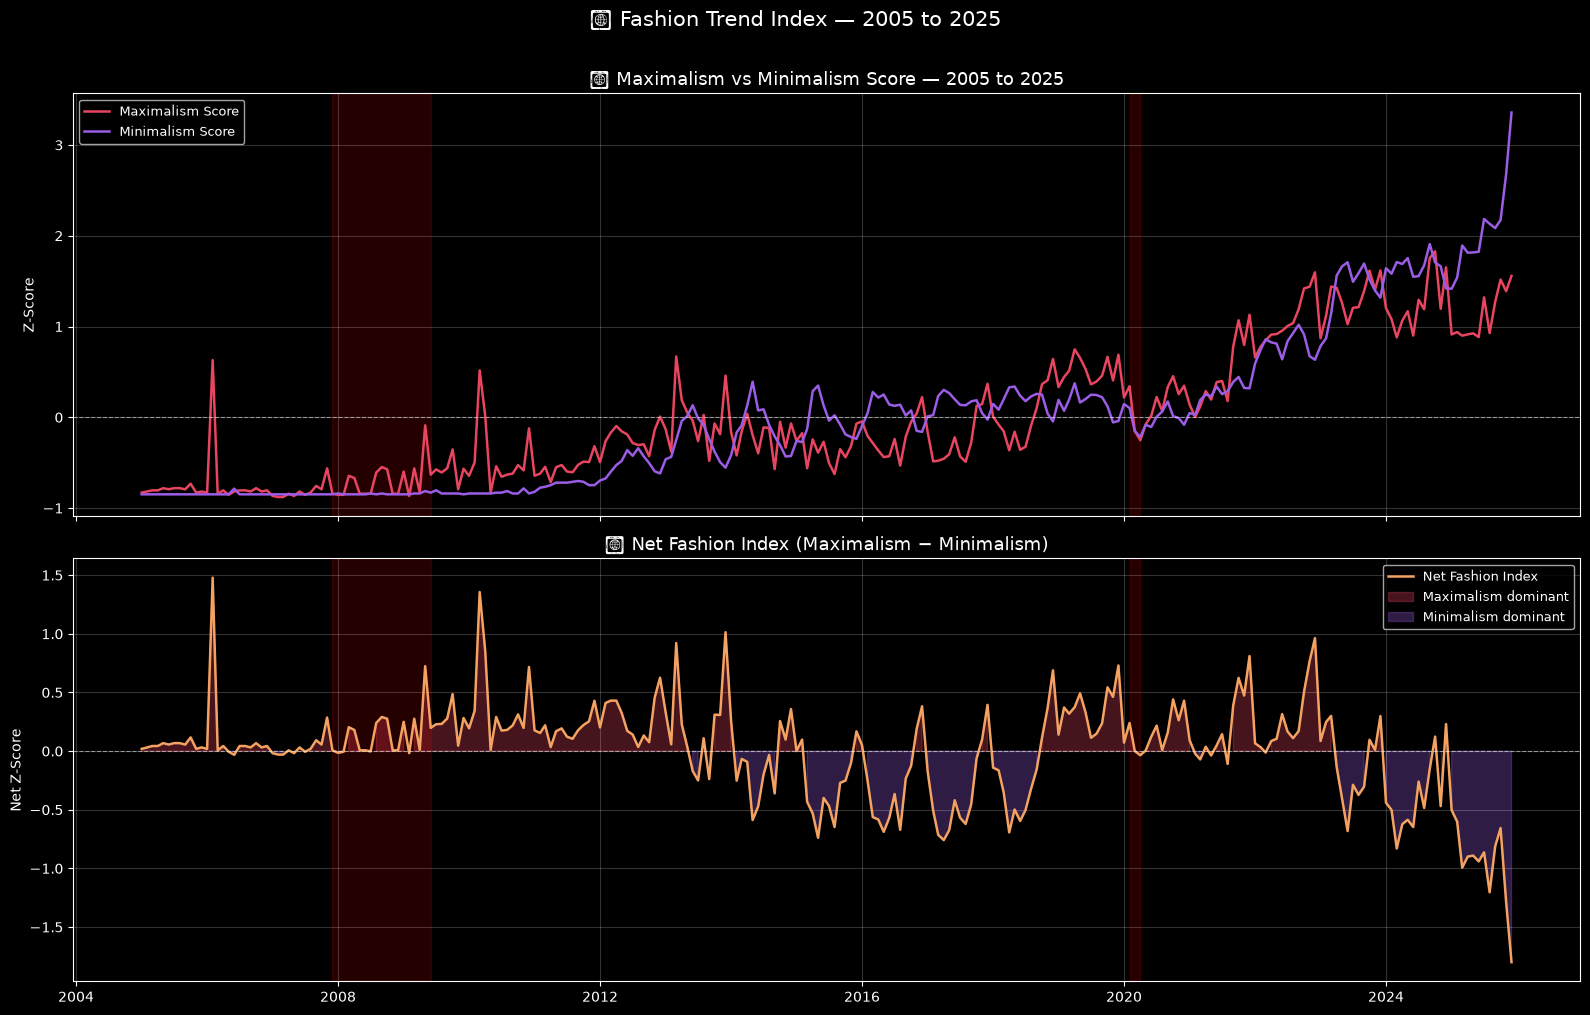

💾 Saved to ../figures/fashion_index.png


In [12]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top chart — maximalism and minimalism scores separately
axes[0].plot(df_index.index, df_index["maximalism_score"],
             color="#e94560", linewidth=1.8, label="Maximalism Score")
axes[0].plot(df_index.index, df_index["minimalism_score"],
             color="#9b5de5", linewidth=1.8, label="Minimalism Score")
axes[0].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)

for rec_start, rec_end in RECESSIONS:
    axes[0].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

axes[0].set_title("📈 Maximalism vs Minimalism Score — 2005 to 2025", fontsize=13)
axes[0].set_ylabel("Z-Score")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

# Bottom chart — net fashion index with fill above/below zero
axes[1].plot(df_index.index, df_index["fashion_index"],
             color="#f4a261", linewidth=1.8, label="Net Fashion Index")

# Fill green above zero (maximalism dominating) and red below (minimalism dominating)
axes[1].fill_between(df_index.index, df_index["fashion_index"], 0,
                     where=df_index["fashion_index"] >= 0,
                     alpha=0.3, color="#e94560", label="Maximalism dominant")
axes[1].fill_between(df_index.index, df_index["fashion_index"], 0,
                     where=df_index["fashion_index"] < 0,
                     alpha=0.3, color="#9b5de5", label="Minimalism dominant")
axes[1].axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.5)

for rec_start, rec_end in RECESSIONS:
    axes[1].axvspan(pd.Timestamp(rec_start), pd.Timestamp(rec_end),
                    alpha=0.15, color="red")

axes[1].set_title("📊 Net Fashion Index (Maximalism − Minimalism)", fontsize=13)
axes[1].set_ylabel("Net Z-Score")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.2)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.suptitle("🎨 Fashion Trend Index — 2005 to 2025", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("../figures/fashion_index.png", dpi=150)
plt.show()
print("💾 Saved to ../figures/fashion_index.png")

## 💾 Section 6: Save Fashion Index

### 📍 Export to CSV

In [13]:
INDEX_PATH = "../data/processed/fashion_index.csv"
df_index.to_csv(INDEX_PATH)

# Also save the normalised keyword data for reference in NB03
NORM_PATH = "../data/processed/fashion_trends_normalised.csv"
df_normalised.to_csv(NORM_PATH)

print("✅ Files saved:")
print(f"   📄 ../data/raw/fashion_trends_raw.csv")
print(f"   📄 {INDEX_PATH}")
print(f"   📄 {NORM_PATH}")
print(f"\n📐 Fashion index shape : {df_index.shape}")
print(f"📅 Date range          : {df_index.index[0].date()} → {df_index.index[-1].date()}")
print(f"\n🚀 Ready for NB03 — Exploratory Analysis & Merging")

✅ Files saved:
   📄 ../data/raw/fashion_trends_raw.csv
   📄 ../data/processed/fashion_index.csv
   📄 ../data/processed/fashion_trends_normalised.csv

📐 Fashion index shape : (252, 3)
📅 Date range          : 2005-01-01 → 2025-12-01

🚀 Ready for NB03 — Exploratory Analysis & Merging


## 🪞 Personal Reflection Notes — NB02

**🎯 Key Decisions Made in This Notebook**

The first decision was to pull keywords individually rather than in batches of five. pytrends normalises search volumes within each batch, meaning if five keywords are pulled together, the values are scaled relative to each other rather than independently. A keyword with much lower absolute search volume than the others would be compressed to near-zero, making it appear less significant than it actually is. By pulling each keyword separately and normalising them ourselves using z-scores, every keyword competes on equal footing regardless of its absolute popularity level.

The second decision was to construct a composite index by averaging keyword z-scores rather than using any single keyword as the fashion proxy. Individual keywords are noisy — a single celebrity wearing a sequin outfit to an awards show can spike "sequin outfit" searches for one month without reflecting any genuine broader trend shift. Averaging across five keywords in each basket smooths out these idiosyncratic spikes and produces a more reliable signal of the underlying aesthetic direction. The composite index is therefore more robust than any single
keyword would be.

The third decision was to define the net fashion index as maximalism minus minimalism rather than treating them as two separate dependent variables. A single net index is cleaner for regression — it produces one number that captures the direction of the fashion cycle, positive meaning maximalism is dominating and negative meaning minimalism is dominating. This directly mirrors how we framed the research question: not whether maximalism is high or minimalism is high independently, but which aesthetic is winning at any given moment.

The fourth decision was to use geo="US" to restrict Google Trends to US searches, matching our economic data which is also US-specific. A global search volume index would introduce noise from markets where fashion trends and economic conditions diverge significantly from the US — for example, Chinese consumers were in a very different economic regime in 2022 than American consumers.

**📊 What the Charts Revealed**

The keyword trends chart produced several interesting findings. On the maximalist side, Y2K fashion was essentially zero until around 2020-2021 when it surged sharply and became the dominant maximalist keyword by 2022-2025 — exactly matching the cultural moment when Gen Z embraced early 2000s aesthetics on TikTok. Mini skirt and sequin outfit showed a steady upward trend from 2020 onwards, consistent with the post-COVID revenge dressing phenomenon where consumers overcorrected toward expressive fashion after two years of lockdowns. Logomania remained relatively flat throughout — suggesting it was never a mass consumer search trend even during its fashion industry peak around 2018-2019.

On the minimalist side, maxi skirt showed a surprising spike around 2011-2014 before declining — this likely reflects the boho-maxi trend of the early 2010s rather than the minimalist quiet luxury aesthetic we are trying to capture, which is a limitation of using broad keywords. Quiet luxury was essentially zero until 2022 when it exploded, precisely when consumer sentiment was falling sharply due to inflation. Capsule wardrobe and neutral outfit both showed gradual upward trends from 2018 onwards, consistent with the slow rise of the minimalist movement that accelerated after COVID.

The fashion index chart is the most revealing. The net index was broadly positive (maximalism dominant) from 2005 through roughly 2013, which aligns with the pre-crisis boom and early recovery period. It then shifted into negative territory (minimalism dominant) around 2014-2019 — the decade of normcore, athleisure, and understated dressing that dominated the 2010s recovery. Post-COVID the index briefly spiked positive in 2021-2022 (revenge dressing) before crashing deeply negative by 2024-2025 as quiet luxury, capsule wardrobes, and neutral tones completely dominated search interest.

The most striking observation is the sharp negative dive in the net index from 2023 onwards, which coincides exactly with the period when consumer sentiment in NB01 was falling to its lowest levels despite low unemployment. This preliminary visual alignment is exactly the relationship we are trying to formalise in NB03 — whether falling consumer confidence predicts a shift toward minimalism.

**🔜 What This Sets Up for NB03**

The net fashion index shows clear regime shifts over the 21-year period that visually correspond to economic cycles, which is an encouraging signal before any formal statistical analysis. NB03 will merge this fashion index with the economic indicators from NB01, run a correlation matrix to quantify the relationship, and test whether economic indicators at different lag lengths predict the fashion index — capturing whether fashion responds to economic conditions immediately or with a delay.